In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

from data_augmentation.matrices_loader import MatricesLoader
from utils.io_utils import *
from analytic_methods.EVM_method import EVM
from visualization.results.metrics_visualizator import MetricsVisualizator
from visualization.data.weights_visualizator import WeightsVisualizator
from metrics.evaluator import Evaluator
from model.trainers.graph_trainer import GraphTrainer
from model.loss_function.graph.custom_graph_loss import CustomGraphLoss
from model.architecture.GAT import GAT
from model.architecture.GAT_v2 import GATv2
from model.loss_function.graph.COP_optimized_graph_loss import COPOptimizedGraphLoss

/home/konra/semestr6/sieci_neuronowe/NN-preference-modeling/venv_gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cpu


In [3]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4, 0.45, 0.5]
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

BATCH_SIZE = 1024
LEARNING_RATE = 5e-4

In [ ]:
def compare_results_batch(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrices, weights_vectors, pred_weights_vectors in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        mae_nn, kendal_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)

        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))
        all_mae_nn.append(np.mean(mae_nn))
        all_kendall_taus_nn.append(np.mean(kendal_taus_nn))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)


def compare_results_dict(solver, evaluator, matrices: dict, weights: dict, predicted_priority_weights: dict):
    cr_values = np.array(sorted(list(matrices.keys())))

    all_mae_evm = []
    all_kendall_taus_evm = []

    for cr in cr_values:
        test_matrices = matrices[cr]
        weights_vectors = weights[cr]
        
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        
        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)

    mae_errors_nn_list = []
    kendall_taus_nn_list = []
    nn_names_list = []

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(cr_values)} consistency rates.")
    print(f"Global mean CR: {np.mean(cr_values):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}")
    print("-" * 40)

    for nn_name, pred_cr_dict in predicted_priority_weights.items():
        nn_names_list.append(nn_name)
        all_mae_nn = []
        all_kendall_taus_nn = []

        for cr in cr_values:
            weights_vectors = weights[cr]
            pred_weights_vectors = pred_cr_dict[cr]

            mae_nn, kendall_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)
            
            all_mae_nn.append(np.mean(mae_nn))
            all_kendall_taus_nn.append(np.mean(kendall_taus_nn))

        final_mae_nn = np.array(all_mae_nn)
        final_kendall_taus_nn = np.array(all_kendall_taus_nn)

        mae_errors_nn_list.append(final_mae_nn)
        kendall_taus_nn_list.append(final_kendall_taus_nn)

        print(f"Network: {nn_name}")
        print(f"  -> Global mean MAE: {np.mean(final_mae_nn):.4f}")
        print(f"  -> Global mean Kendall correlation: {np.mean(final_kendall_taus_nn):.4f}")
        print("-" * 40)

    viz = MetricsVisualizator()
    viz.plot_comparison_lists(
        cr_values=cr_values,
        mae_errors_analytic=final_mae_evm,
        kendall_taus_analytic=final_kendall_taus_evm,
        mae_errors_nn=mae_errors_nn_list,
        kendall_taus_nn=kendall_taus_nn_list,
        nn_name=nn_names_list
    )

In [18]:
loader = MatricesLoader()
train_dataset = load_train_dataset_graph(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_graph(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

Train dataset was successfully created and 230000 matrices was uploaded
Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully up

In [19]:
COP = 1
REC = 2
STAB = 0.2
MODEL_TYPE = "graph"
MODEL_NAME = f"GAT_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = GAT(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomGraphLoss(n_criteria=CRITERIA_NUM, lambda_cop=COP, lambda_rec=REC, lambda_stab=STAB).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = GraphTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.426458 | Valid Loss: 0.409831 | Valid MAE: 0.0640
Epoch number 14: Learning Rate was reduced to 0.000250
Epoch number [20/500] | Train Loss: 0.424536 | Valid Loss: 0.405204 | Valid MAE: 0.0635
Epoch number [30/500] | Train Loss: 0.423757 | Valid Loss: 0.405954 | Valid MAE: 0.0635
Epoch number 39: Learning Rate was reduced to 0.000125
Epoch number [40/500] | Train Loss: 0.423601 | Valid Loss: 0.406770 | Valid MAE: 0.0637
Epoch number 45: Learning Rate was reduced to 0.000063

EARLY STOPPING in epoch 48.
Wages are restored to the best valid loss: 0.403557
History and model: GAT_10000m_5crit was saved in models/graph/cop100_rec200_stab20


In [20]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 5).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0633
Global mean Kendall correlation (EVM): 0.6398, NN: 0.4590


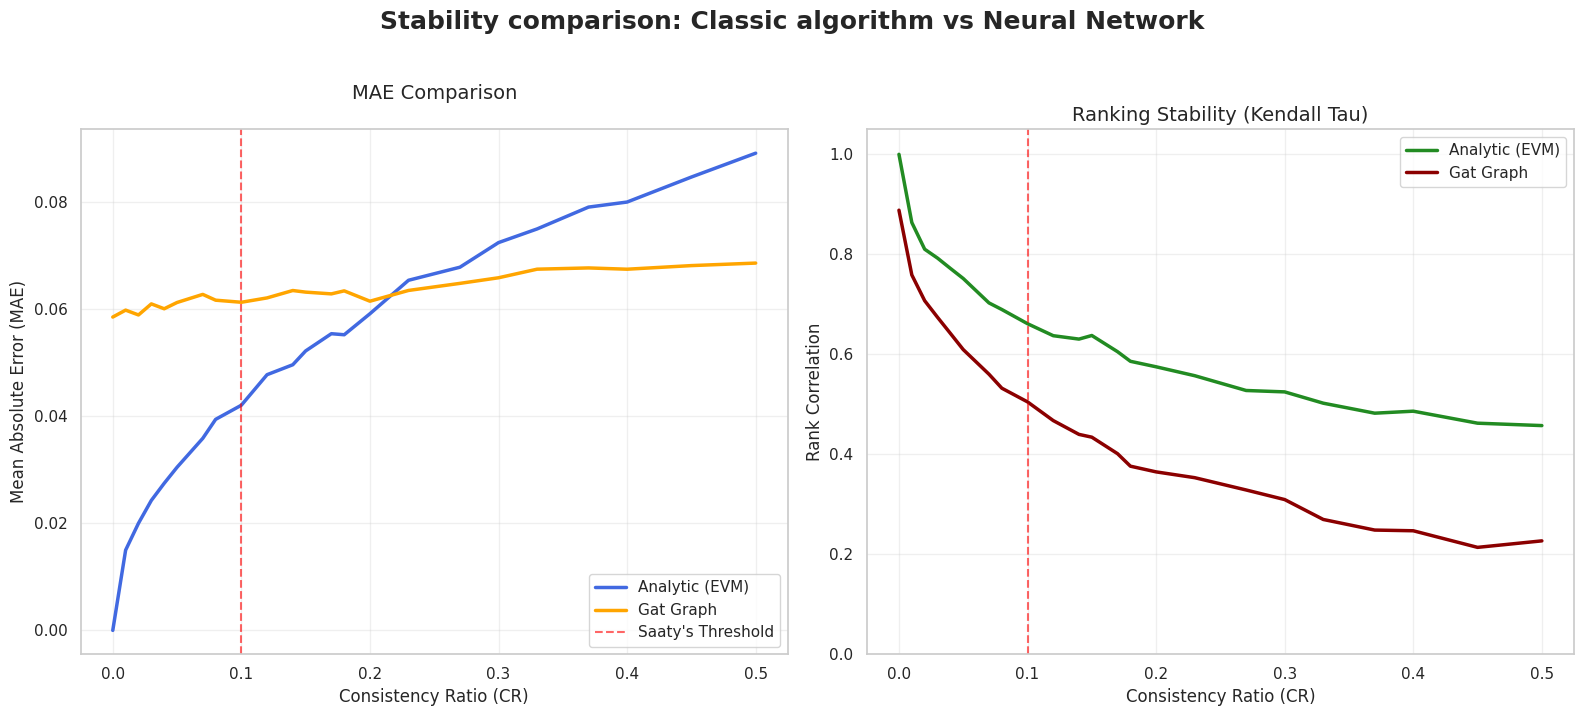

In [21]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

In [ ]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)

## Graph Attention Network v2

In [6]:
loader = MatricesLoader()
train_dataset = load_train_dataset_graph(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_graph(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 1
REC = 2
STAB = 0.2
MODEL_TYPE = "graph"
MODEL_NAME = f"advanced_GAT_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = GATv2(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomGraphLoss(n_criteria=CRITERIA_NUM, lambda_cop=COP, lambda_rec=REC, lambda_stab=STAB).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = GraphTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.193821 | Valid Loss: 0.182231 | Valid MAE: 0.0503
Epoch number [20/500] | Train Loss: 0.185645 | Valid Loss: 0.176625 | Valid MAE: 0.0515
Epoch number [30/500] | Train Loss: 0.182354 | Valid Loss: 0.174785 | Valid MAE: 0.0521
Epoch number [40/500] | Train Loss: 0.180381 | Valid Loss: 0.173208 | Valid MAE: 0.0525
Epoch number [50/500] | Train Loss: 0.179114 | Valid Loss: 0.172649 | Valid MAE: 0.0521
Epoch number [60/500] | Train Loss: 0.178292 | Valid Loss: 0.173011 | Valid MAE: 0.0529
Epoch number 64: Learning Rate was reduced to 0.000250
Epoch number [70/500] | Train Loss: 0.177352 | Valid Loss: 0.171734 | Valid MAE: 0.0537
Epoch number 73: Learning Rate was reduced to 0.000125
Epoch number 79: Learning Rate was reduced to 0.000063
Epoch number [80/500] | Train Loss: 0.176743 | Valid Loss: 0.171358 | Valid MAE: 0.0537

EARLY STOPPING in epoch 82.
Wages are restored to the best valid loss: 0.171156
History and model: advanced_GAT_10000m_5crit was s

In [8]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 5).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0531
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6008


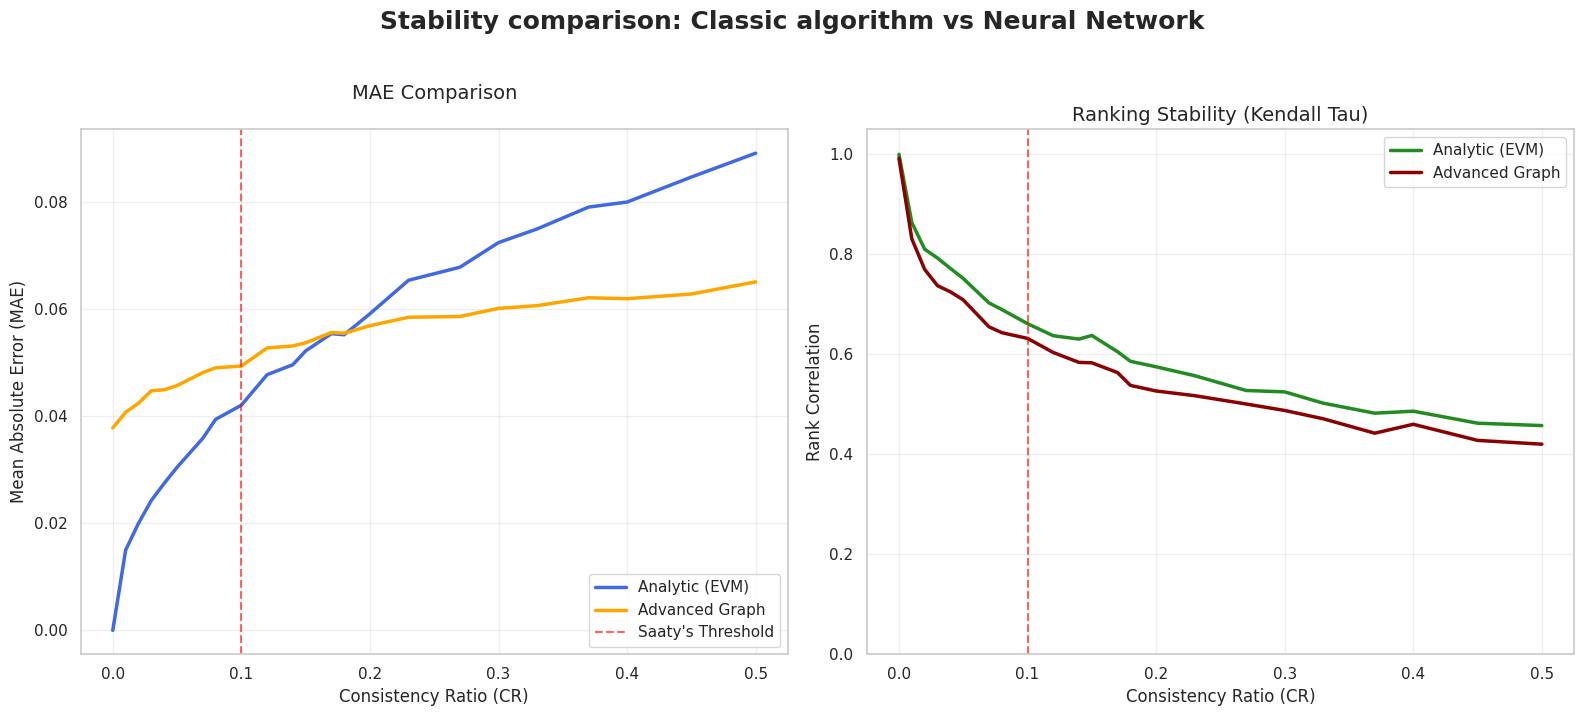

In [9]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

## Optimized COP 

In [10]:
COP = 1
REC = 2
STAB = 0.2
MODEL_TYPE = "graph"
MODEL_NAME = f"GAT_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = GAT(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedGraphLoss(n_criteria=CRITERIA_NUM, lambda_cop=COP, lambda_rec=REC, lambda_stab=STAB).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = GraphTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.498688 | Valid Loss: 0.493949 | Valid MAE: 0.0716
Epoch number [20/500] | Train Loss: 0.492653 | Valid Loss: 0.488560 | Valid MAE: 0.0716
Epoch number [30/500] | Train Loss: 0.491046 | Valid Loss: 0.486923 | Valid MAE: 0.0720
Epoch number 31: Learning Rate was reduced to 0.000250
Epoch number [40/500] | Train Loss: 0.490585 | Valid Loss: 0.486401 | Valid MAE: 0.0721
Epoch number 43: Learning Rate was reduced to 0.000125
Epoch number 49: Learning Rate was reduced to 0.000063
Epoch number [50/500] | Train Loss: 0.490675 | Valid Loss: 0.486469 | Valid MAE: 0.0721

EARLY STOPPING in epoch 52.
Wages are restored to the best valid loss: 0.485786
History and model: GAT_10000m_5crit was saved in models/graph/cop100_rec200_stab20


In [11]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 5).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0720
Global mean Kendall correlation (EVM): 0.6398, NN: 0.1352


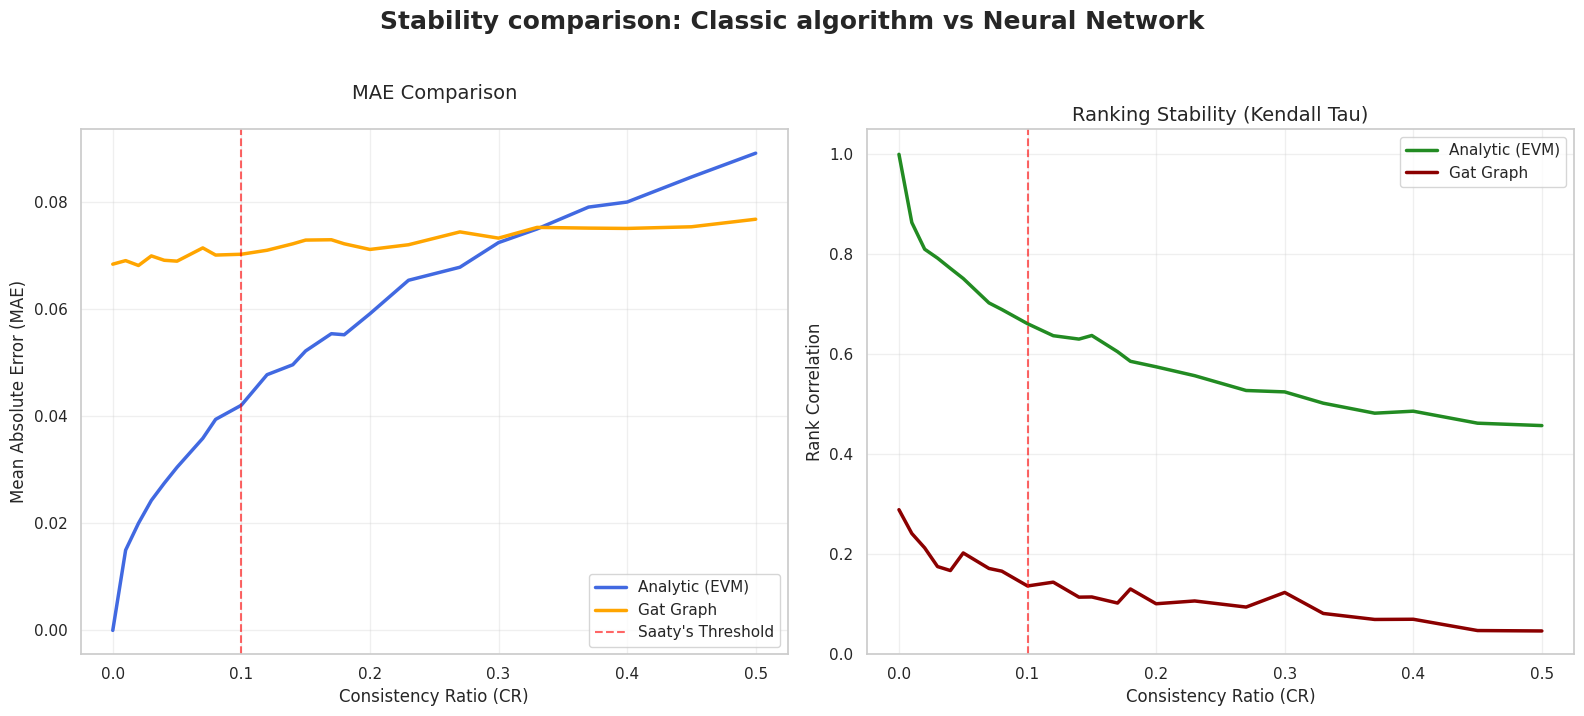

In [12]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### GAT v2

In [ ]:
COP = 1
REC = 2
STAB = 0.2
MODEL_TYPE = "graph"
MODEL_NAME = f"advanced_GAT_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit"

model = GATv2(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomGraphLoss(n_criteria=CRITERIA_NUM, lambda_cop=COP, lambda_rec=REC, lambda_stab=STAB).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = GraphTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.189173 | Valid Loss: 0.178400 | Valid MAE: 0.0510
Epoch number [20/500] | Train Loss: 0.182845 | Valid Loss: 0.174857 | Valid MAE: 0.0519
Epoch number [30/500] | Train Loss: 0.180351 | Valid Loss: 0.173039 | Valid MAE: 0.0531
Epoch number 36: Learning Rate was reduced to 0.000250
Epoch number [40/500] | Train Loss: 0.179020 | Valid Loss: 0.172935 | Valid MAE: 0.0526
Epoch number 49: Learning Rate was reduced to 0.000125
Epoch number [50/500] | Train Loss: 0.178195 | Valid Loss: 0.172559 | Valid MAE: 0.0532
Epoch number 55: Learning Rate was reduced to 0.000063

EARLY STOPPING in epoch 58.
Wages are restored to the best valid loss: 0.172310
History and model: advanced_GAT_10000m_5crit was saved in models/graph/cop100_rec200_stab20


In [14]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 5).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0527
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6028


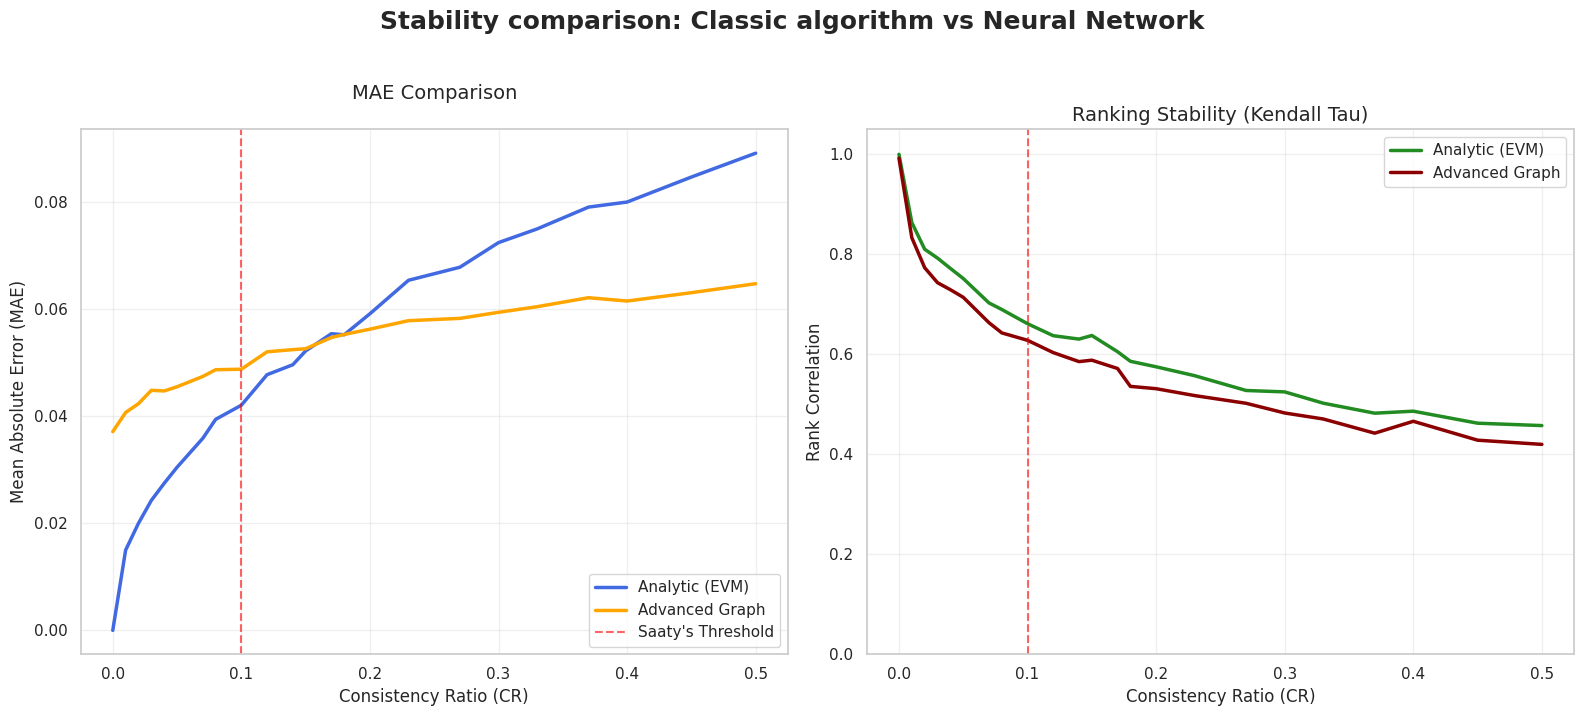

In [15]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

## Wnioski

Ograniczenia architektur grafowych względem sieci syjamskich w problemie stabilności wag priorytetów ujawniły, że mimo zastosowania zaawansowanych mechanizmów uwagi grafowej, architektury z rodziny GNN ustępują wydajnością topologiczną (Kendall Tau) wielowarstwowym sieciom syjamskim. Wynika to z kilku ograniczeń algorytmów na grafach w kontekście analizy macierzy decyzyjnych

### 1. Ograniczenie grafów w pełni połączonych
Paradygmat działania sieci grafowych opiera się na tzw. przekazywaniu wiadomości między sąsiadami. Z punktu widzenia teorii grafów, macierz AHP jest kliką - grafem w pełni połączonym, każde kryterium łączy się bezpośrednio z każdym innym. Agregacja informacji w takim środowisku powoduje, że już po 2-3 warstwach reprezentacje wszystkich węzłów stają się do siebie niebezpiecznie podobne. Zjawisko to, znane jako oversmoothing, prowadzi do zapaści logitów. Sieć grafowa zaczyna zwracać uśrednione priorytety, drastycznie obniżając współczynnik Kendall Tau. Sieć syjamska jest wolna od tego problemu, ponieważ uczy się z globalnego układu tensora, a nie z wymuszonej agregacji sąsiedztwa.

### 2. Brak przestrzeni cech początkowych
Modele grafowe, takie jak GAT, osiągają wybitne rezultaty w zadaniach, gdzie węzły posiadają bogate wektory cech (np. parametry cząsteczek chemicznych lub profile użytkowników). W problemie AHP kryteria to puste byty matematyczne. Na wejściu otrzymują sztuczne, identyczne inicjalizatory. Sieć grafowa zmuszona jest wyciągnąć całą topologię wyłącznie na podstawie samych krawędzi - ułamków Saaty'ego. W przeciwieństwie do niej, sieć syjamska, analizując od razu całe wektory wierszowe macierzy, nie potrzebuje atrybutów węzłów, by natychmiast uchwycić relacje siły np. że kryterium $i$ zdominowało wiersz.

### 3. Redundancja i rozmycie uwagi
Choć zastosowanie GATv2 z dynamiczną uwagą i parametrem edge_dim=1 pozwoliło na uwzględnienie wag eksperta (co poprawiło wyniki na drugim wykresie), mechanizm ten wciąż pozostaje nieefektywny dla macierzy AHP. Ponieważ graf nie ma ukrytej struktury - nie ma brakujących połączeń ani rzadkości, uwaga sieci ulega rozmyciu na dziesiątki relacji wejściowych i wyjściowych jednocześnie. Sieć syjamska rozwiązuje to dużo prościej i brutalniej – po spłaszczeniu macierzy do jednego wektora połączonego ze współdzielonymi wagami, sieć tworzy bezpośrednie i niezależne odwzorowania statystyczne, nie tracąc zasobów na obliczanie i normalizację współczynników sąsiedztwa.

### Podsumowując: 
grafowe sieci neuronowe powstały po to, aby analizować strukturę połączeń. W problemie AHP kształt grafu jest zawsze identyczny (każdy z każdym), a cała informacja leży wyłącznie w wartościach krawędzi. Używanie skomplikowanego GNN do analizy w pełni połączonej kliki to jak strzelanie z armaty do muchy – matematyczny narzut konwolucji grafowej przynosi więcej szkody niż pożytku.